# 车辆轨迹提取：逐步实现与中间结果可视化

这个 Notebook 按步骤展示当前算法（峰图 + 动态规划 + NMS）的实现过程，并在每一步绘制中间结果。

流程：
1. 加载 SAC 数据与窗口裁剪
2. 高斯模板增强
3. 候选峰检测
4. 速度窗约束（边构建直觉）
5. 单条最优轨迹（DP）
6. 多轨迹迭代提取（NMS）
7. 与 backend 全流程结果对比
8. 不同引擎（CPU/GPU）速度对比


In [12]:
from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

from auto_track_backend import AutoTrackBackend, DEFAULT_DATA_FOLDER
from track_extractor_graph import (
    ExtractorConfig,
    _build_nodes,
    _extract_best_track,
    _suppress_nodes,
)

plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## 0) 参数设置

In [13]:
DATA_FOLDER = DEFAULT_DATA_FOLDER
WINDOW_START_S = 1200.0
WINDOW_SECONDS = 120.0

DIRECTION = "forward"            # forward / reverse
SPEED_MIN_KMH = 60.0
SPEED_MAX_KMH = 120.0

CFG = ExtractorConfig(
    sigma_seconds=(0.06, 0.10, 0.14, 0.18),
    enhance_decimate=2,
    prominence=0.4,
    min_peak_distance=500,
    min_track_channels=12,
    nms_time_radius=180,
)

MAX_TRACKS_DEMO = 30

print("DATA_FOLDER:", DATA_FOLDER)
print("WINDOW:", WINDOW_START_S, "->", WINDOW_START_S + WINDOW_SECONDS, "s")
print("SPEED:", SPEED_MIN_KMH, "~", SPEED_MAX_KMH, "km/h")
print("CONFIG:", CFG)


DATA_FOLDER: /Volumes/SanDisk2T4/MyProjects/BaFang/KF/data/synthetic_sac
WINDOW: 1200.0 -> 1320.0 s
SPEED: 60.0 ~ 120.0 km/h
CONFIG: ExtractorConfig(sigma_seconds=(0.06, 0.1, 0.14, 0.18), enhance_decimate=2, prominence=0.4, min_peak_distance=500, max_skip_channels=4, lambda_speed=2.0, lambda_skip=0.55, speed_change_tolerance_kmh=18.0, speed_penalty_power=0.85, speed_penalty_cap=2.5, min_track_channels=12, min_track_score=10.0, edge_relax_enabled=True, edge_min_track_channels=6, edge_time_margin_seconds=15.0, edge_min_score_scale=0.55, nms_time_radius=180, nms_channel_radius=1, max_tracks=256, max_peaks_per_channel=400)


In [14]:
def _robust_global_scale(data_plot: np.ndarray) -> float:
    eps = 1e-12
    abs_vals = np.abs(data_plot[np.isfinite(data_plot)])
    if abs_vals.size == 0:
        return 1.0
    q995 = float(np.quantile(abs_vals, 0.995))
    rms = float(np.sqrt(np.mean(abs_vals * abs_vals)))
    return max(q995, 3.0 * rms, eps)


def plot_section_wiggle(
    ax,
    data: np.ndarray,
    t_abs: np.ndarray,
    offsets_m: np.ndarray,
    target_points_per_trace: int = 3500,
    color: str = "0.45",
    lw: float = 0.75,
    alpha: float = 0.9,
):
    n_ch, n_samples = data.shape
    decim = int(max(1, np.ceil(n_samples / float(target_points_per_trace))))
    t = t_abs[::decim]
    data_plot = np.asarray(data[:, ::decim], dtype=np.float64)
    offsets_km = np.asarray(offsets_m, dtype=np.float64) * 1e-3

    if offsets_km.size >= 2:
        spacing = float(np.median(np.diff(offsets_km)))
        if (not np.isfinite(spacing)) or spacing <= 0:
            spacing = 0.1
    else:
        spacing = 0.1

    wiggle_amp = 0.27 * spacing
    clip_ratio = 1.35
    global_ref = _robust_global_scale(data_plot)

    for i in range(n_ch):
        ratio = np.clip(data_plot[i] / global_ref, -clip_ratio, clip_ratio)
        y = offsets_km[i] + ratio * wiggle_amp
        ax.plot(t, y, color=color, linewidth=lw, alpha=alpha)

    pad = 0.4 * spacing
    ax.set_ylim(offsets_km.min() - pad, offsets_km.max() + pad)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Offset [km]")


def overlay_tracks(
    ax,
    tracks,
    time_offset_s: float = 0.0,
    cmap_name: str = "tab20",
    lw: float = 1.4,
    s: float = 12.0,
    alpha_line: float = 0.95,
):
    cmap = plt.cm.get_cmap(cmap_name, max(1, len(tracks)))
    for i, tr in enumerate(tracks):
        if len(tr.points) < 2:
            continue
        pts = sorted(tr.points, key=lambda p: p.ch_idx)
        ts = np.array([p.time_s + time_offset_s for p in pts], dtype=np.float64)
        ys = np.array([p.offset_m * 1e-3 for p in pts], dtype=np.float64)
        color = cmap(i % max(1, cmap.N))
        ax.plot(ts, ys, color=color, linewidth=lw, alpha=alpha_line)
        ax.scatter(ts, ys, color=[color], s=s, alpha=0.9)

        if np.isfinite(float(tr.mean_speed_kmh)):
            mid = len(ts) // 2
            ax.text(
                ts[mid],
                ys[mid],
                f"{float(tr.mean_speed_kmh):.1f} km/h",
                color=color,
                fontsize=8,
                ha="left",
                va="center",
                bbox={"facecolor": "white", "alpha": 0.55, "edgecolor": "none", "pad": 0.6},
            )


## 1) 加载数据 + 原始 section

data shape=(50, 120000), fs=1000.000Hz, dx=100.00m
window=[1200.0, 1320.0] s


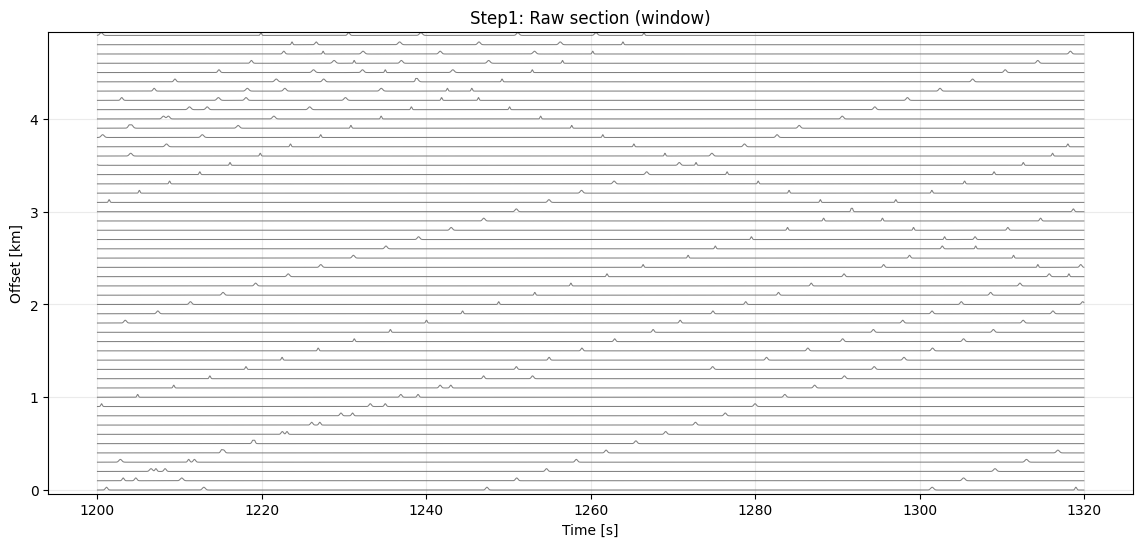

In [15]:
backend = AutoTrackBackend(data_folder=DATA_FOLDER)
if backend.init_error:
    raise RuntimeError(backend.init_error)

backend.window_size = int(round(WINDOW_SECONDS * backend.fs))
backend.current_start = int(round(WINDOW_START_S * backend.fs))
backend.update_view_window()

data = backend.data_view
fs = float(backend.fs)
dx_m = float(backend.dx_m)
window_t0 = float(backend.current_start) / fs
window_t1 = float(backend.current_start + backend.window_size) / fs
t_abs = np.arange(data.shape[1], dtype=np.float64) / fs + window_t0
offsets_m = backend.x_axis_m.copy()

print(f"data shape={data.shape}, fs={fs:.3f}Hz, dx={dx_m:.2f}m")
print(f"window=[{window_t0:.1f}, {window_t1:.1f}] s")

fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m)
ax.set_title("Step1: Raw section (window)")
plt.show()


## 2) 高斯模板增强（每道 |signal| 与多个 sigma 卷积取 max）

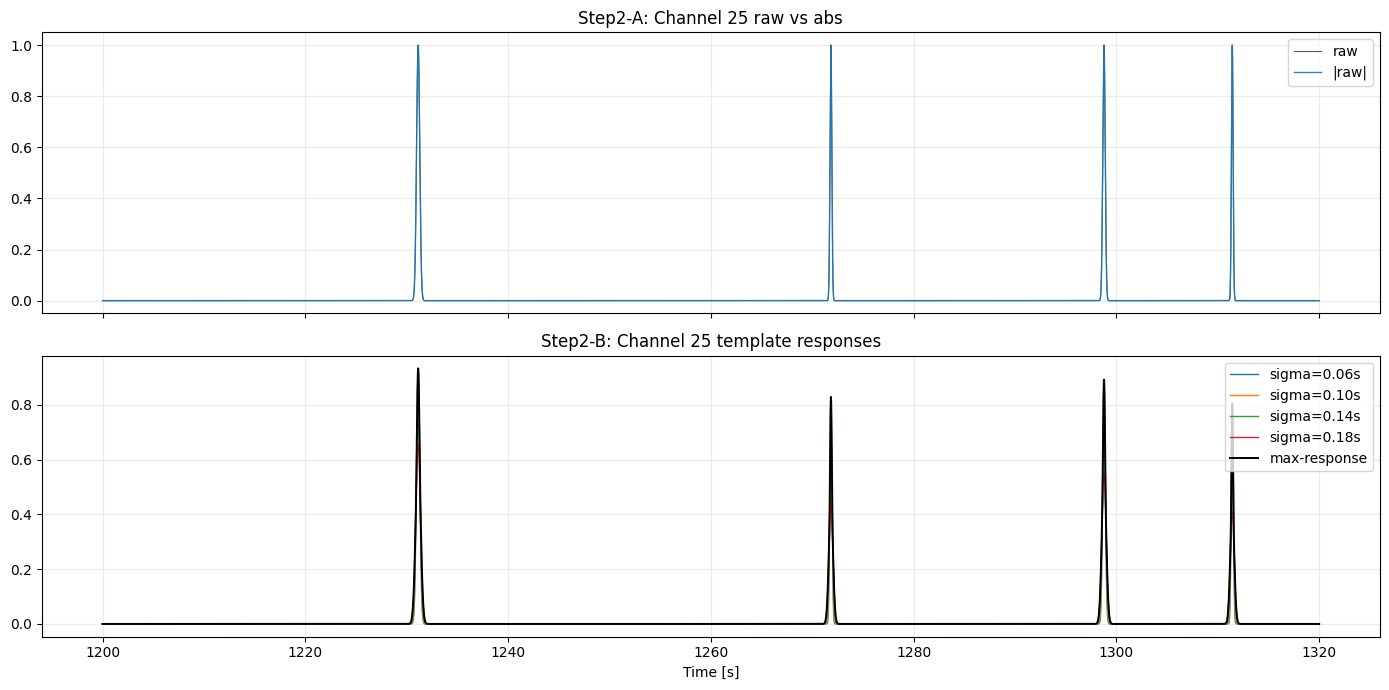

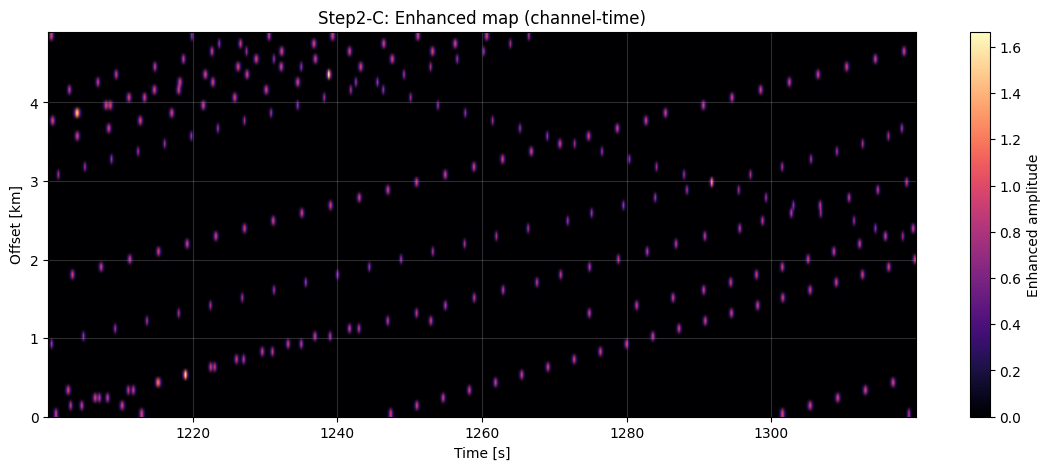

In [16]:
abs_data = np.abs(data).astype(np.float32)
enhanced_list = []
for sigma_s in CFG.sigma_seconds:
    sigma_samples = max(1.0, sigma_s * fs)
    resp = gaussian_filter1d(abs_data, sigma=sigma_samples, axis=1, mode="nearest")
    enhanced_list.append(resp.astype(np.float32, copy=False))
enhanced = np.maximum.reduce(enhanced_list)

ch_demo = int(data.shape[0] // 2)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t_abs, data[ch_demo], color="0.35", lw=0.8, label="raw")
axes[0].plot(t_abs, abs_data[ch_demo], color="tab:blue", lw=1.0, alpha=0.9, label="|raw|")
axes[0].set_title(f"Step2-A: Channel {ch_demo} raw vs abs")
axes[0].legend(loc="upper right")

for i, sigma_s in enumerate(CFG.sigma_seconds):
    axes[1].plot(t_abs, enhanced_list[i][ch_demo], lw=1.0, label=f"sigma={sigma_s:.2f}s")
axes[1].plot(t_abs, enhanced[ch_demo], color="k", lw=1.4, label="max-response")
axes[1].set_title(f"Step2-B: Channel {ch_demo} template responses")
axes[1].set_xlabel("Time [s]")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    enhanced,
    aspect="auto",
    origin="lower",
    extent=[t_abs[0], t_abs[-1], offsets_m[0] * 1e-3, offsets_m[-1] * 1e-3],
    cmap="magma",
)
ax.set_title("Step2-C: Enhanced map (channel-time)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Offset [km]")
fig.colorbar(im, ax=ax, label="Enhanced amplitude")
plt.show()


## 3) 候选峰检测（prominence + min distance）

candidate count: 228
mean candidates/channel: 4.56


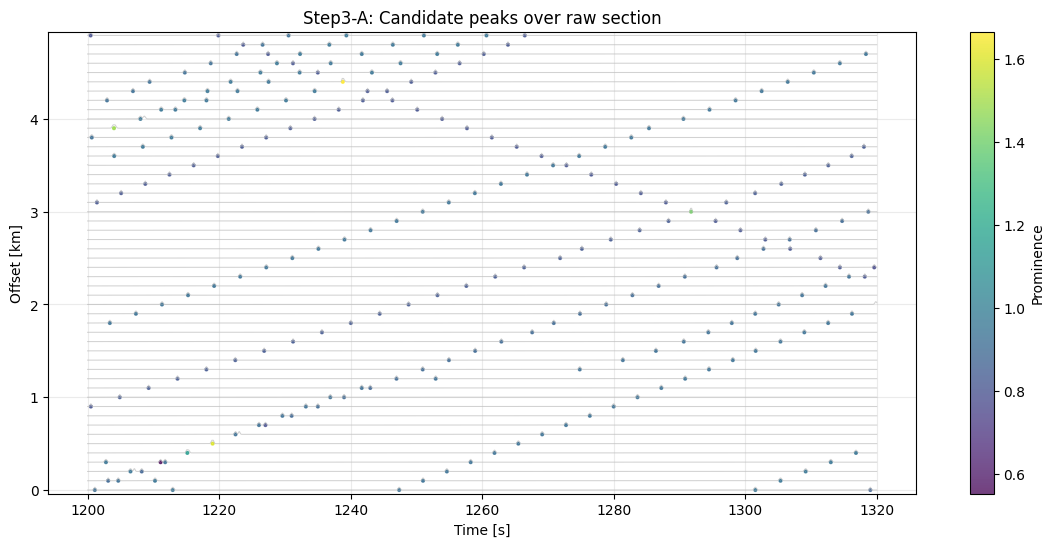

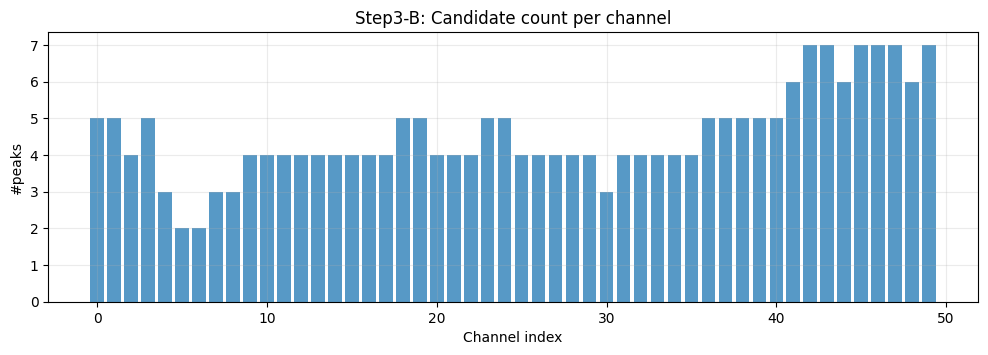

In [17]:
peak_distance = int(max(1, CFG.min_peak_distance))
peak_nodes = []
all_t = []
all_y = []
all_s = []

for ch in range(data.shape[0]):
    peaks, props = find_peaks(
        enhanced[ch],
        prominence=CFG.prominence,
        distance=peak_distance,
    )
    if peaks.size == 0:
        peak_nodes.append((np.empty((0,), dtype=np.int32), np.empty((0,), dtype=np.float32)))
        continue
    prom = props.get("prominences", np.zeros(peaks.shape[0], dtype=np.float32)).astype(np.float32)
    peak_nodes.append((peaks.astype(np.int32, copy=False), prom))

    all_t.append((peaks / fs + window_t0).astype(np.float64))
    all_y.append(np.full(peaks.shape, offsets_m[ch] * 1e-3, dtype=np.float64))
    all_s.append(prom.astype(np.float64))

if all_t:
    cand_t = np.concatenate(all_t)
    cand_y = np.concatenate(all_y)
    cand_s = np.concatenate(all_s)
else:
    cand_t = np.empty((0,), dtype=np.float64)
    cand_y = np.empty((0,), dtype=np.float64)
    cand_s = np.empty((0,), dtype=np.float64)

print("candidate count:", cand_t.size)
print("mean candidates/channel:", cand_t.size / max(1, data.shape[0]))

fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m, color="0.75", alpha=0.7)
if cand_t.size:
    sc = ax.scatter(cand_t, cand_y, c=cand_s, s=4, cmap="viridis", alpha=0.75)
    fig.colorbar(sc, ax=ax, label="Prominence")
ax.set_title("Step3-A: Candidate peaks over raw section")
plt.show()

per_ch = np.array([len(x[0]) for x in peak_nodes], dtype=np.int32)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(np.arange(per_ch.size), per_ch, color="tab:blue", alpha=0.75)
ax.set_title("Step3-B: Candidate count per channel")
ax.set_xlabel("Channel index")
ax.set_ylabel("#peaks")
plt.show()


## 4) 速度窗约束可视化（从某个道的一个峰，连接到下一道可行时间范围）

seed channel=25, next channel=26, dx=100.0m
seed time=1231.130s, allowed next time=[1234.130, 1237.130]s
candidates on ch26: total=4, valid=1


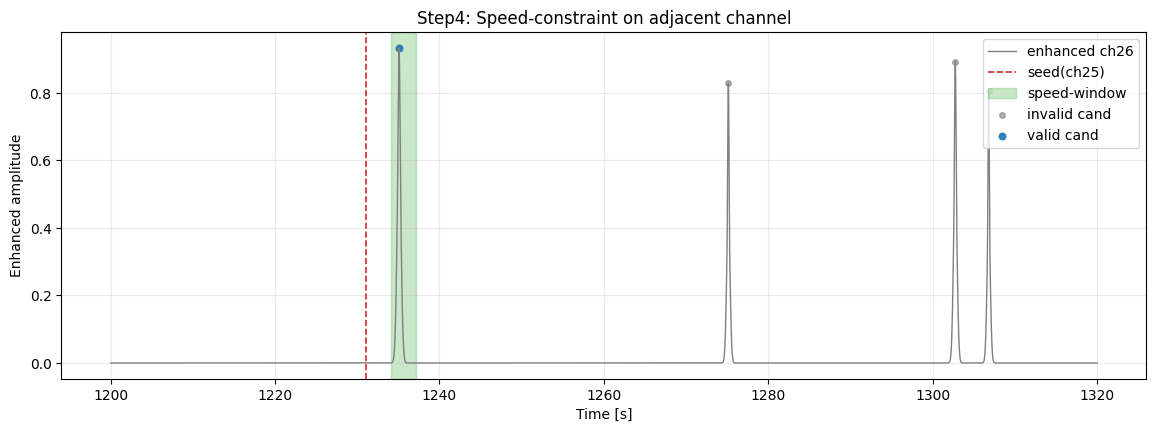

In [18]:
nodes_for_demo = _build_nodes(data, fs=fs, config=CFG)

ch0 = int(data.shape[0] // 2)
ch1 = min(data.shape[0] - 1, ch0 + 1)
if nodes_for_demo[ch0]["t"].size == 0 or nodes_for_demo[ch1]["t"].size == 0:
    raise RuntimeError("演示通道没有候选峰，请调整窗口或阈值。")

seed_idx = int(np.argmax(nodes_for_demo[ch0]["score"]))
seed_t_local = float(nodes_for_demo[ch0]["t"][seed_idx]) / fs
seed_t_abs = seed_t_local + window_t0

dx = abs(float(offsets_m[ch1] - offsets_m[ch0]))
vmin_mps = SPEED_MIN_KMH / 3.6
vmax_mps = SPEED_MAX_KMH / 3.6
if DIRECTION == "forward":
    dt_lo = dx / vmax_mps
    dt_hi = dx / vmin_mps
else:
    dt_lo = -dx / vmin_mps
    dt_hi = -dx / vmax_mps

pred_lo = seed_t_abs + min(dt_lo, dt_hi)
pred_hi = seed_t_abs + max(dt_lo, dt_hi)

cand1_abs = nodes_for_demo[ch1]["t"] / fs + window_t0
valid = (cand1_abs >= pred_lo) & (cand1_abs <= pred_hi)

print(f"seed channel={ch0}, next channel={ch1}, dx={dx:.1f}m")
print(f"seed time={seed_t_abs:.3f}s, allowed next time=[{pred_lo:.3f}, {pred_hi:.3f}]s")
print(f"candidates on ch{ch1}: total={cand1_abs.size}, valid={int(np.sum(valid))}")

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(t_abs, enhanced[ch1], color="0.5", lw=1.0, label=f"enhanced ch{ch1}")
ax.axvline(seed_t_abs, color="tab:red", lw=1.2, ls="--", label=f"seed(ch{ch0})")
ax.axvspan(pred_lo, pred_hi, color="tab:green", alpha=0.25, label="speed-window")
ax.scatter(cand1_abs[~valid], enhanced[ch1, nodes_for_demo[ch1]["t"][~valid]], s=16, color="0.55", alpha=0.7, label="invalid cand")
ax.scatter(cand1_abs[valid], enhanced[ch1, nodes_for_demo[ch1]["t"][valid]], s=22, color="tab:blue", alpha=0.9, label="valid cand")
ax.set_title("Step4: Speed-constraint on adjacent channel")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Enhanced amplitude")
ax.legend(loc="upper right")
plt.show()


## 5) 单条最优轨迹（Dynamic Programming）

best track points: 31
best track mean speed (km/h): 92.582
best track total score: 33.992


/var/folders/wr/ns4vhsl54fzbdxm0z0rd4lk00000gn/T/ipykernel_77908/1406440865.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, max(1, len(tracks)))


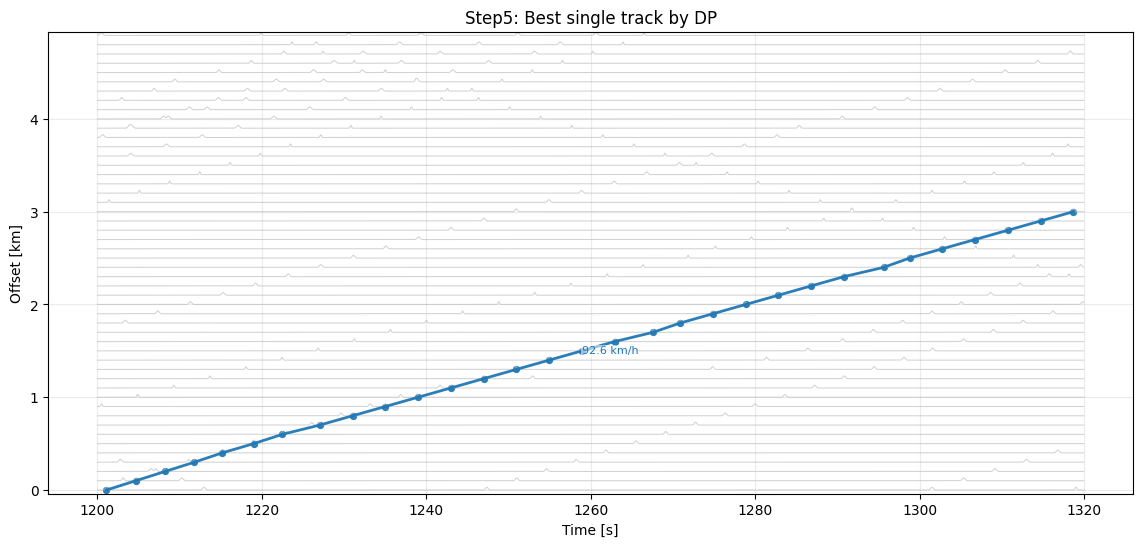

In [19]:
vmin_mps = SPEED_MIN_KMH / 3.6
vmax_mps = SPEED_MAX_KMH / 3.6

nodes_dp = [
    {"t": n["t"].copy(), "amp": n["amp"].copy(), "score": n["score"].copy()}
    for n in nodes_for_demo
]
best_track = _extract_best_track(
    nodes=nodes_dp,
    fs=fs,
    dx_m=dx_m,
    direction=DIRECTION,
    vmin_mps=vmin_mps,
    vmax_mps=vmax_mps,
    n_samples=data.shape[1],
    config=CFG,
    track_id=0,
)

if best_track is None:
    print("当前窗口下未提取到满足条件的轨迹。")
else:
    print("best track points:", len(best_track.points))
    print("best track mean speed (km/h):", round(float(best_track.mean_speed_kmh), 3))
    print("best track total score:", round(float(best_track.total_score), 3))

    fig, ax = plt.subplots(figsize=(14, 6))
    plot_section_wiggle(ax, data, t_abs, offsets_m, color="0.75", alpha=0.7)
    overlay_tracks(ax, [best_track], time_offset_s=window_t0, cmap_name="tab10", lw=2.0, s=18)
    ax.set_title("Step5: Best single track by DP")
    plt.show()


## 6) 多轨迹迭代提取（每次取最优 + NMS 抑制）

iterative tracks: 11
top-10 speeds (km/h):
  track 00: points= 31, speed=  92.58, score=   33.99
  track 01: points= 29, speed=  90.81, score=   32.32
  track 02: points= 28, speed=  85.10, score=   28.53
  track 03: points= 20, speed=  99.37, score=   22.52
  track 04: points= 18, speed=  97.93, score=   18.30
  track 05: points= 14, speed=  83.77, score=   16.16
  track 06: points= 12, speed=  79.41, score=   13.68
  track 07: points= 11, speed=  95.28, score=   11.95
  track 08: points=  7, speed=  91.31, score=    7.25
  track 09: points=  8, speed=  93.60, score=    6.27


/var/folders/wr/ns4vhsl54fzbdxm0z0rd4lk00000gn/T/ipykernel_77908/1406440865.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, max(1, len(tracks)))


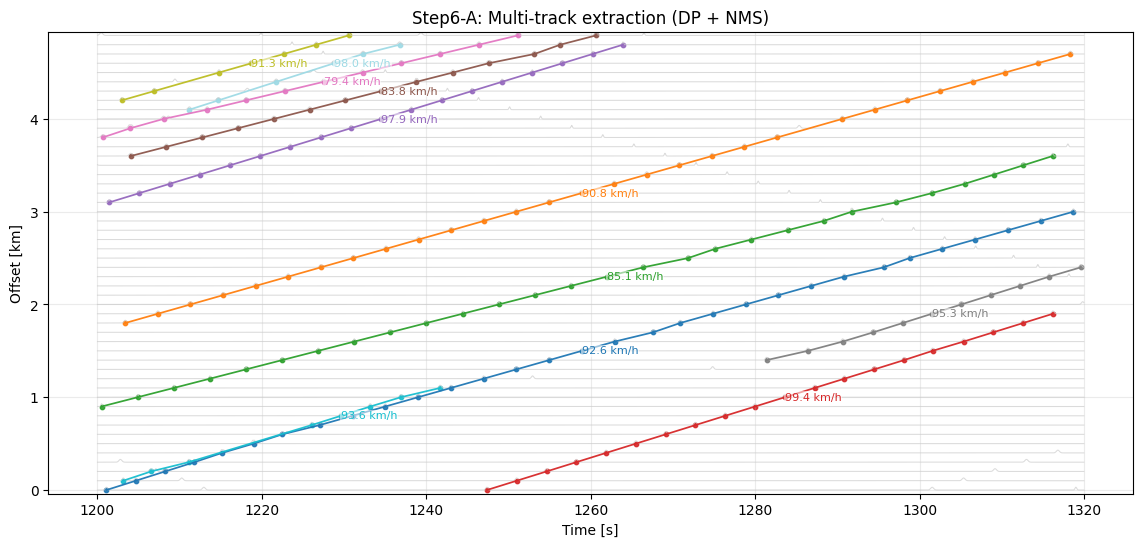

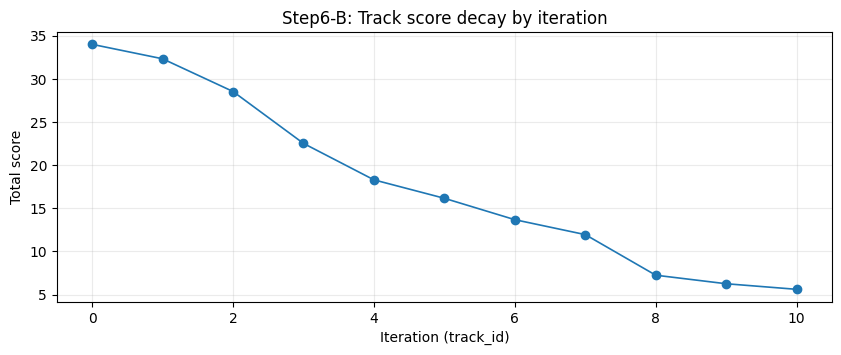

In [20]:
nodes_iter = [
    {"t": n["t"].copy(), "amp": n["amp"].copy(), "score": n["score"].copy()}
    for n in nodes_for_demo
]

tracks_iter = []
for tid in range(MAX_TRACKS_DEMO):
    tr = _extract_best_track(
        nodes=nodes_iter,
        fs=fs,
        dx_m=dx_m,
        direction=DIRECTION,
        vmin_mps=vmin_mps,
        vmax_mps=vmax_mps,
        n_samples=data.shape[1],
        config=CFG,
        track_id=tid,
    )
    if tr is None:
        break
    tracks_iter.append(tr)
    _suppress_nodes(nodes_iter, tr, CFG)

print("iterative tracks:", len(tracks_iter))
if tracks_iter:
    print("top-10 speeds (km/h):")
    for tr in tracks_iter[:10]:
        print(f"  track {tr.track_id:02d}: points={len(tr.points):3d}, speed={float(tr.mean_speed_kmh):7.2f}, score={float(tr.total_score):8.2f}")

fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m, color="0.8", alpha=0.7)
overlay_tracks(ax, tracks_iter, time_offset_s=window_t0, cmap_name="tab20", lw=1.25, s=10)
ax.set_title("Step6-A: Multi-track extraction (DP + NMS)")
plt.show()

if tracks_iter:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot([float(t.total_score) for t in tracks_iter], marker="o", lw=1.2)
    ax.set_title("Step6-B: Track score decay by iteration")
    ax.set_xlabel("Iteration (track_id)")
    ax.set_ylabel("Total score")
    plt.show()


## 7) backend 全流程结果（含跨块 merge / dedup / stitch）

backend summary:
{'track_count': 11, 'total_points': 184, 'avg_points_per_track': 16.727272727272727, 'elapsed_seconds': 1.2037067500059493, 'params': {'direction': 'forward', 'scope': 'current_window', 'engine': 'cpu_parallel', 'engine_text': 'CPU 并行(10线程)', 'parallel_workers': 10, 'gpu_device_id': None, 'speed_min_kmh': 60.0, 'speed_max_kmh': 120.0, 'prominence': 0.4, 'min_peak_distance': 500, 'min_track_channels': 12, 'tile_seconds': 120.0, 'overlap_seconds': 20.0, 'nms_time_radius_seconds': 0.18000001098632878, 'window_start_sample': 1200000, 'window_end_sample': 1320000, 'extractor_config': {'sigma_seconds': [0.06, 0.1, 0.14, 0.18], 'enhance_decimate': 2, 'max_skip_channels': 4, 'lambda_speed': 2.0, 'lambda_skip': 0.55, 'speed_change_tolerance_kmh': 18.0, 'speed_penalty_power': 0.85, 'speed_penalty_cap': 2.5, 'min_track_score': 10.0, 'nms_channel_radius': 1}, 'stitch_config': {'max_gap_channels': 8, 'dt_slack_ratio': 0.35, 'max_speed_diff_kmh': 35.0}}}


/var/folders/wr/ns4vhsl54fzbdxm0z0rd4lk00000gn/T/ipykernel_77908/1406440865.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, max(1, len(tracks)))


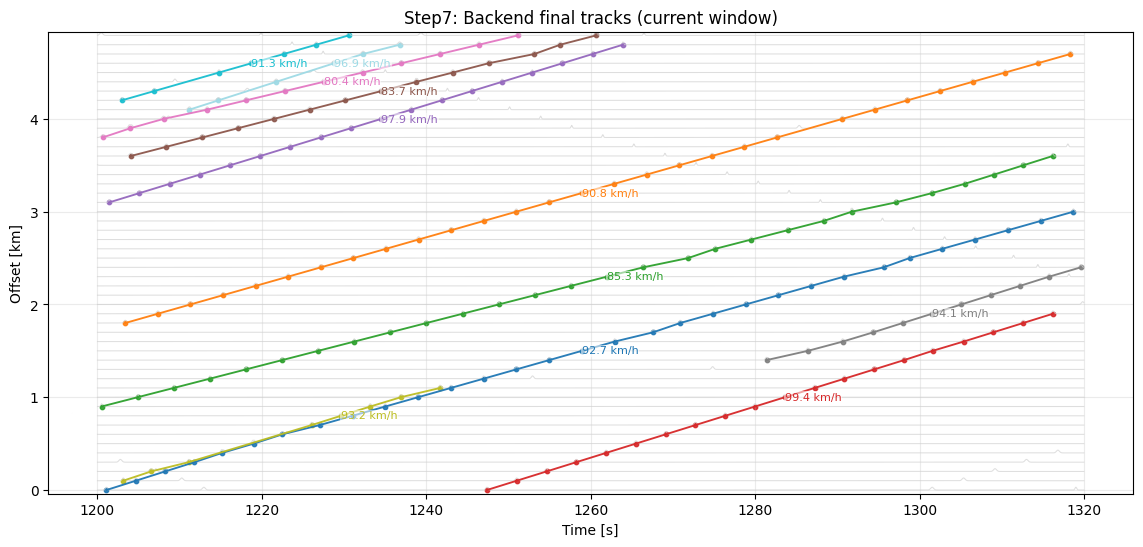

In [21]:
summary = backend.run_auto_extract(
    engine="cpu_parallel",
    direction=DIRECTION,
    speed_min_kmh=SPEED_MIN_KMH,
    speed_max_kmh=SPEED_MAX_KMH,
    prominence=CFG.prominence,
    min_peak_distance=CFG.min_peak_distance,
    min_track_channels=CFG.min_track_channels,
    tile_seconds=120,
    overlap_seconds=20,
    nms_time_radius=CFG.nms_time_radius / fs,
    current_window_only=True,
)

print("backend summary:")
print(summary)

tracks_backend = backend.tracks
fig, ax = plt.subplots(figsize=(14, 6))
plot_section_wiggle(ax, data, t_abs, offsets_m, color="0.82", alpha=0.7)
overlay_tracks(ax, tracks_backend, time_offset_s=0.0, cmap_name="tab20", lw=1.35, s=10)
ax.set_title("Step7: Backend final tracks (current window)")
plt.show()


## 8) 引擎速度对比（当前窗口）

('cpu_single', 'ok', 1.1608732090098783, 11)
('cpu_parallel', 'ok', 1.242186125018634, 11)
('gpu_torch_mps', 'ok', 0.32465554200462066, 11)
('gpu', 'fail: 未检测到可用CuPy。请先安装与CUDA版本匹配的cupy包，例如 cupy-cuda12x。', 0.00024575000861659646, 0)


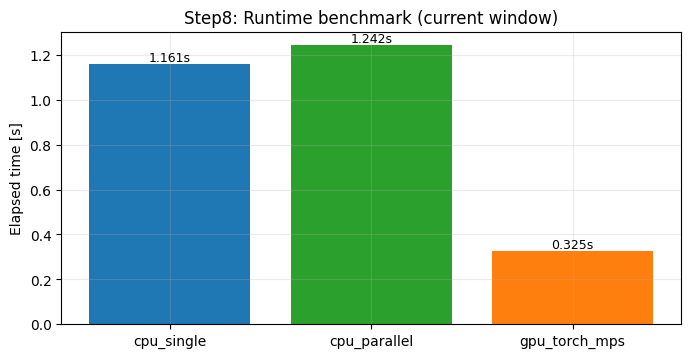

In [22]:
engines = ["cpu_single", "cpu_parallel", "gpu_torch_mps", "gpu"]
bench = []

for eng in engines:
    t0 = time.perf_counter()
    try:
        s = backend.run_auto_extract(
            engine=eng,
            direction=DIRECTION,
            speed_min_kmh=SPEED_MIN_KMH,
            speed_max_kmh=SPEED_MAX_KMH,
            prominence=CFG.prominence,
            min_peak_distance=CFG.min_peak_distance,
            min_track_channels=CFG.min_track_channels,
            tile_seconds=120,
            overlap_seconds=20,
            nms_time_radius=CFG.nms_time_radius / fs,
            current_window_only=True,
        )
        dt = float(time.perf_counter() - t0)
        bench.append((eng, "ok", dt, int(s.get("track_count", 0))))
    except Exception as e:  # noqa: BLE001
        dt = float(time.perf_counter() - t0)
        bench.append((eng, f"fail: {e}", dt, 0))

for row in bench:
    print(row)

ok_rows = [r for r in bench if r[1] == "ok"]
if ok_rows:
    fig, ax = plt.subplots(figsize=(8, 3.8))
    names = [r[0] for r in ok_rows]
    times = [r[2] for r in ok_rows]
    ax.bar(names, times, color=["tab:blue", "tab:green", "tab:orange", "tab:red"][:len(ok_rows)])
    ax.set_title("Step8: Runtime benchmark (current window)")
    ax.set_ylabel("Elapsed time [s]")
    for i, v in enumerate(times):
        ax.text(i, v, f"{v:.3f}s", ha="center", va="bottom", fontsize=9)
    plt.show()


## 说明

- 这个 Notebook 侧重“算法过程可解释性”，因此展示了大量中间图。
- GUI 中使用的是同一条算法链路，参数保持一致即可得到一致趋势。
- 如果你想把这些图自动导出成报告（PNG + Markdown），可以在这个 Notebook 基础上再加一段批量保存单元。